# US Firm Characteristics: Feasibility Analysis

`config/setup.yaml` declares a monthly cross-sectional long-short strategy over the
Chen-Pelger-Zhu (2020) anonymized firm-characteristics panel: which firms are eligible,
how often the book turns over, what a round trip is assumed to cost, how the sample is
split. This notebook asks whether the data supports those declarations, and fits nothing.

## Learning objectives

- Count the cross-section on the date the strategy acts on, and read the share of monthly
  moves clearing an assumed round trip off an exceedance curve
- Measure how long a firm keeps its place in a characteristic ranking, and confirm the
  declared folds fit the sample without touching the holdout

## Book reference

Chapter 6, Sections 6.2-6.6. Reads the released panel through `load_firm_characteristics`
and `config/setup.yaml`, and writes nothing.

## Prerequisites

Walk-forward cross-validation, Section 6.5, and the trading setup the case study declares.

In [1]:
"""US Firm Characteristics Case Study - Feasibility Analysis."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from matplotlib.ticker import PercentFormatter

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_firm_characteristics
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
START_DATE = "1990-01-01"
END_DATE = "2016-12-31"

## Configuration

Every knob is read from `setup.yaml`, and Section B computes on the development window
alone, so nothing the holdout contains can shape a choice made here. The three
characteristics carried through Section B are one apiece from the families Section C's
kill conditions name; the ranking the strategy trades uses all of them.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = str(SETUP["labels"]["buffer"])
BREADTH_FLOOR = 2 * max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
LEG_BPS = SETUP["costs"]["per_leg_cost_bps_range"]
ROUND_TRIP_BPS = (2 * LEG_BPS[0], 2 * LEG_BPS[1])
COST_LO, COST_HI = ROUND_TRIP_BPS[0] / 1e4, ROUND_TRIP_BPS[1] / 1e4
CARRIERS = {"BEME": "book-to-market", "PROF": "profitability", "r12_2": "momentum"}
ACF_LAGS = 12

print(
    f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END} | "
    f"breadth floor {BREADTH_FLOOR} firms | assumed round trip {ROUND_TRIP_BPS} bps"
)

Development 1990-01-01 to 2016-01-01 | sealed holdout to 2016-12-31 | breadth floor 100 firms | assumed round trip (10, 40) bps


## A. Orientation

Firm characteristics are the standard input to cross-sectional asset pricing: accounting
ratios, price-based measures and turnover proxies, ranked across firms each month and
read as a forecast of the coming month's return. This release is anonymized, its firm
axis is persistent only inside each published block, and every retained row carries the
complete characteristic set, so the universe is the provider's completeness rule rather
than a liquidity screen. Three questions decide whether the declared setup is buildable:
is the cross-section wide enough on every decision date to fill both legs, is a typical
monthly move large next to what crossing it costs, and are there enough decision dates
for a walk-forward that never reads the holdout.

## B. Universe and cost feasibility

### B.1 Load and seal the development window

The loader returns one row per firm and month, with the realized monthly return in `ret`.
The holdout is cut once, here, so everything below runs on data a design choice may see.

In [4]:
window = pl.col("timestamp").is_between(
    pl.lit(START_DATE).str.to_date(), pl.lit(END_DATE).str.to_date(), closed="both"
)
research = (
    load_firm_characteristics(split="all")
    .filter(window & (pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date()))
    .sort(["symbol", "timestamp"])
)

assert not set(CARRIERS) - set(research.columns), "a characteristic is absent from the release"
assert research["timestamp"].max() < np.datetime64(HOLDOUT_START), "the frame reaches the holdout"
print(
    f"{research['symbol'].n_unique():,} firms, {len(research):,} firm-months, "
    f"{research['timestamp'].min()} to {research['timestamp'].max()}"
)

9,793 firms, 780,882 firm-months, 1990-01-31 to 2015-12-31


### B.2 Breadth at every decision date

A cross-sectional book is filled on the date it rebalances, so what decides whether the
strategy is buildable is firms per month, not firms in the sample. The reference line is
both legs of the largest portfolio the sweep grid asks for.

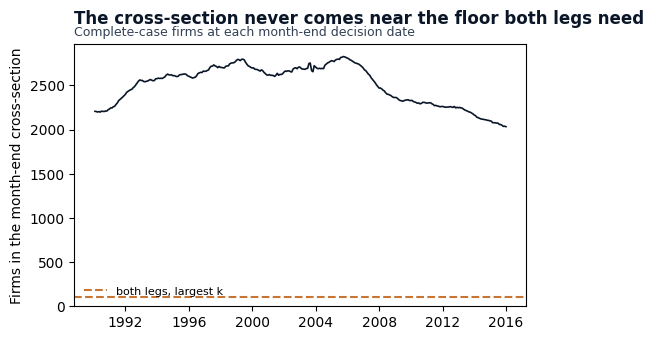

In [5]:
breadth = research.group_by("timestamp").agg(pl.len().alias("n_firms")).sort("timestamp")

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["timestamp"], breadth["n_firms"], color=COLORS["blue"], linewidth=1.2)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="both legs, largest k")
ax.set_ylim(0, None)
ax.set_ylabel("Firms in the month-end cross-section")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "The cross-section never comes near the floor both legs need",
    subtitle="Complete-case firms at each month-end decision date",
)
plt.show()

### B.3 What a move is worth against what a round trip costs

The release publishes ranks, not prices: no quote, no volume and no share count reaches
this notebook, so a per-firm cost cannot be measured from it and `setup.yaml::costs`
declares a per-leg band instead, doubled here into the round trip a rebalance pays. A
long-short sorts within the monthly cross-section, so start with how wide that is.

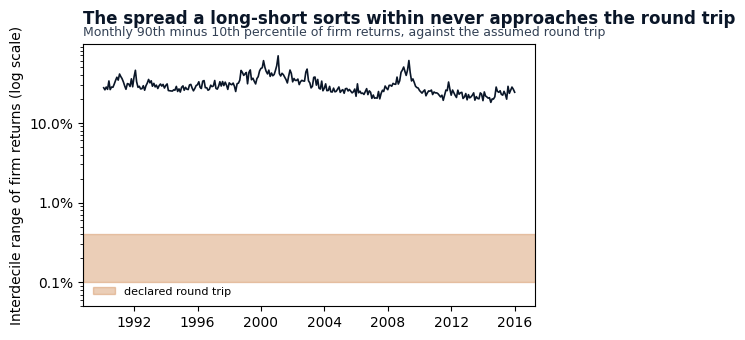

In [6]:
returns = research.select("timestamp", "ret").drop_nulls("ret")
dispersion = (
    returns.group_by("timestamp")
    .agg((pl.col("ret").quantile(0.9) - pl.col("ret").quantile(0.1)).alias("interdecile"))
    .sort("timestamp")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(dispersion["timestamp"], dispersion["interdecile"], color=COLORS["blue"], lw=1.2)
ax.axhspan(COST_LO, COST_HI, color=COLORS["copper"], alpha=0.35, label="declared round trip")
ax.set_yscale("log")
ax.set_ylim(COST_LO / 2, None)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.set_ylabel("Interdecile range of firm returns (log scale)")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "The spread a long-short sorts within never approaches the round trip",
    subtitle="Monthly 90th minus 10th percentile of firm returns, against the assumed round trip",
)
plt.show()

That spread widens in stress and has drifted down since the dot-com era: the opportunity
narrows rather than the cost rising. The exceedance curve asks the cost question
directly - pick a magnitude and the curve gives the fraction of firm-months that moved at
least that far, so where it crosses the band is the share that covered the round trip.

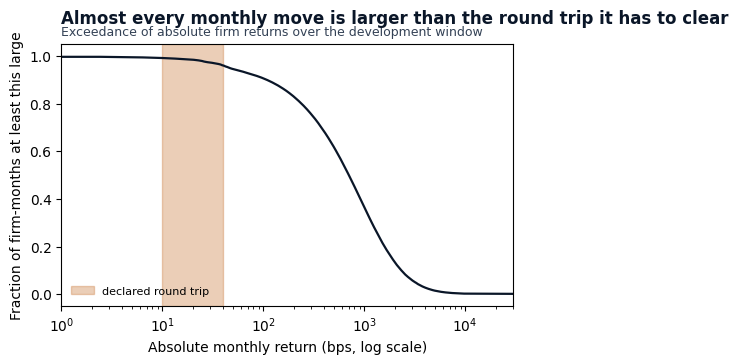

In [7]:
magnitude, fraction = exceedance_curve(returns["ret"].abs().to_numpy())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(magnitude * 1e4, fraction, color=COLORS["blue"], lw=1.6)
ax.axvspan(*ROUND_TRIP_BPS, color=COLORS["copper"], alpha=0.35, label="declared round trip")
ax.set_xscale("log")
ax.set_xlim(1, 3e4)
ax.set_xlabel("Absolute monthly return (bps, log scale)")
ax.set_ylabel("Fraction of firm-months at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Almost every monthly move is larger than the round trip it has to clear",
    subtitle="Exceedance of absolute firm returns over the development window",
)
plt.show()

### B.4 How long a firm keeps its place in the ranking

Rebalancing monthly is only worth the turnover if what a characteristic says at one
month-end still says something at the next. Each characteristic is a cross-sectional
rank, so the question is how fast a firm's position in that ranking decays. The
autocorrelation is computed inside each firm and then pooled: stacking thousands of firms
and correlating the result would measure the joins between them. Firms whose monthly
history has a gap are dropped, because a gap reads as a lag it is not, and so are firms
too short for the longest lag to be estimated from.

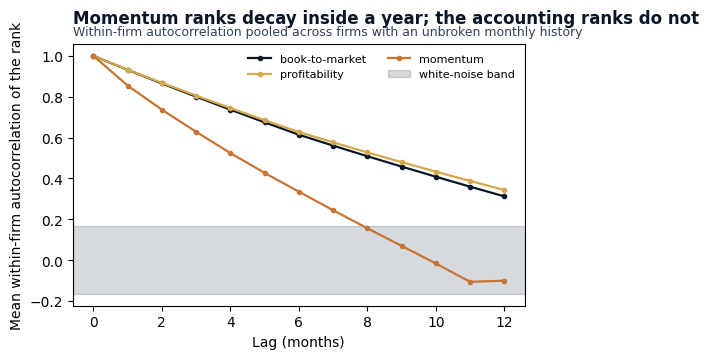

In [8]:
months = research.select("timestamp").unique().sort("timestamp").with_row_index("month")
indexed = research.join(months, on="timestamp")
unbroken = (
    indexed.group_by("symbol")
    .agg(pl.len().alias("n"), (pl.col("month").max() - pl.col("month").min() + 1).alias("span"))
    .filter(pl.col("n") == pl.col("span"))  # months observed == months between first and last
    .select("symbol")
)
carriers = indexed.join(unbroken, on="symbol").sort(["symbol", "timestamp"])
acfs = {
    # Four times the longest lag is the shortest history an ACF at that lag is read from.
    name: panel_acf(carriers, entity_col="symbol", value_col=name, max_lags=ACF_LAGS, min_obs=48)
    for name in CARRIERS
}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
palette = (COLORS["blue"], COLORS["amber"], COLORS["copper"])
for (name, label), color in zip(CARRIERS.items(), palette, strict=True):
    acf = acfs[name]
    ax.plot(acf["lag"], acf["acf"], color=color, lw=1.6, marker="o", ms=3, label=label)
band = float(acfs[next(iter(CARRIERS))]["band"][0])
ax.axhspan(-band, band, color=COLORS["neutral"], alpha=0.2, label="white-noise band")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Mean within-firm autocorrelation of the rank")
ax.legend(frameon=False, fontsize=8, ncol=2)
add_message_title(
    ax,
    "Momentum ranks decay inside a year; the accounting ranks do not",
    subtitle="Within-firm autocorrelation pooled across firms with an unbroken monthly history",
)
plt.show()

### B.5 Move scale against cost

The ratio divides the median absolute monthly move by the midpoint of the declared round
trip, and the clearance share counts moves above its upper bound. Neither is a forecast:
an unsigned move is a magnitude, and nothing here says which side of it a position sat.

In [9]:
absolute = returns.select(pl.col("ret").abs().alias("move"))
median_move_bps = float(absolute["move"].median()) * 1e4
clears_cost = float((absolute["move"] > ROUND_TRIP_BPS[1] / 1e4).mean())
print(
    f"Median absolute monthly move {median_move_bps:.0f} bps against a round trip of "
    f"{ROUND_TRIP_BPS[0]} to {ROUND_TRIP_BPS[1]} bps, ratio "
    f"{median_move_bps / np.mean(ROUND_TRIP_BPS):.0f}x | share clearing the upper "
    f"bound {clears_cost:.3f}"
)

Median absolute monthly move 706 bps against a round trip of 10 to 40 bps, ratio 28x | share clearing the upper bound 0.961


The median absolute monthly move is 706 bps against an assumed round trip of 10 to 40
bps, a ratio of 28x, and 0.961 of firm-months move further than the upper bound of that
band.

## C. Design decisions

### C.1 Cadence

`setup.yaml::decision.cadence` snapshots at the month-end close and executes at the next
open. The release is monthly, so there is no faster grid to thin from, and B.4 shows the
accounting ranks moving slowly enough that a faster book would trade rank flips rather
than information. The provider refreshes annual variables at the end of June and monthly
ones at month-end for the following month, and publishes no filing dates.

### C.2 Kill conditions

Four declared thresholds send the strategy back to the drawing board, each tested where
its evidence exists rather than here: no characteristic family reaching its
information-coefficient floor under a corrected t-statistic; net performance failing once
costs and borrow are charged; every premium disappearing once size and momentum are
controlled for; either leg concentrating in the least liquid released quantile.

### C.3 Mapping class

`setup.yaml::mapping.class` ranks firms on the model score and holds both tails, because
the bottom of a characteristic sort carries information a long-only book would discard.
The short leg needs borrow, charged as a flat annual rate here and varying sharply by
name in practice. Sizing is equal weight inside each leg, adding no second optimization
on top of the ranking being evaluated.

## D. Walk-forward structure

### D.1 Effective sample size

What evaluation spends is decision dates, not rows: a fold trained on ten years of this
panel sees as many training periods as there are month-ends in it, however many firms
each carries.

In [10]:
print(
    f"Months {research['timestamp'].n_unique():,} | firms {research['symbol'].n_unique():,} "
    f"| median firms per decision date {breadth['n_firms'].median():,.0f}"
)

Months 312 | firms 9,793 | median firms per decision date 2,588


### D.2 Fold demonstration

`generate_cv_splits` derives the folds from `setup.yaml::evaluation` alone. Between each
training and validation block sits a purge gap the width of the label buffer, so a label
computed at the end of training cannot resolve inside validation. The figure draws those
boundaries rather than recomputing them, so it and the folds cannot disagree.

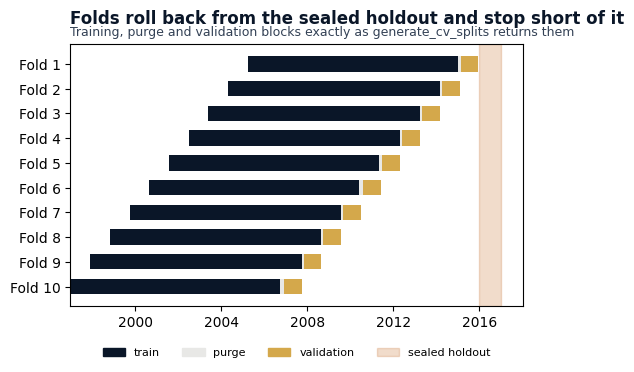

In [11]:
splits = generate_cv_splits(
    research.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
last_val = max(split["val_end"] for split in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
add_message_title(
    ax,
    "Folds roll back from the sealed holdout and stop short of it",
    subtitle="Training, purge and validation blocks exactly as generate_cv_splits returns them",
)
plt.show()

## E. Derived artifacts

None: the completeness rule fixes the universe, so nothing downstream reads an
eligibility table from here and this notebook writes no file.

## F. Findings vs `setup.yaml`

One row per knob: the evidence that motivates it, and what would change it.

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.inclusion_rule` | B.2 breadth per decision date | breadth falls under the count both legs of the largest portfolio need |
| `decision.cadence` | B.3 exceedance, B.4 persistence | moves stop clearing the round trip, or a traded rank decays inside one rebalancing interval |
| `costs.per_leg_cost_bps_range` | B.3, and the absence of any quote in the release | a per-firm cost becomes measurable, or the book moves into names the band does not cover |
| `mapping.class` | B.2 breadth against both legs | one side cannot be filled, or borrow on the short side stops being available |
| `evaluation.n_splits` | D.1 decision dates, D.2 boundaries | the folds no longer fit the development window |

In [12]:
print(
    f"universe.inclusion_rule {SETUP['universe']['inclusion_rule']} | mapping.class "
    f"{SETUP['mapping']['class']} | decision.cadence {SETUP['decision']['cadence']}\n"
    f"firms per decision date {breadth['n_firms'].min():,} to {breadth['n_firms'].max():,}, under "
    f"the floor on {breadth.filter(pl.col('n_firms') < BREADTH_FLOOR).height} of {len(breadth)} "
    f"dates | costs.per_leg_cost_bps_range {LEG_BPS} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, validation "
    f"{min(split['val_start'] for split in splits).date()} to {last_val.date()}, holdout untouched"
)

universe.inclusion_rule complete_characteristic_case | mapping.class long_short_top_k_rebalance | decision.cadence monthly_month_end
firms per decision date 2,032 to 2,826, under the floor on 0 of 312 dates | costs.per_leg_cost_bps_range [5, 20] | labels.primary fwd_ret_1m
evaluation.n_splits 10, generated 10, validation 2006-11-30 to 2015-11-30, holdout untouched


The month-end cross-section runs from 2032 to 2826 firms and clears the floor on every
one of the 312 decision dates. Ten folds are generated, their validation blocks covering
2006-11-30 to 2015-11-30, and the sealed year begins after the last of them.

## Key takeaways

1. **Count the universe on the date the strategy rebalances**, against the positions both
   legs of the largest configuration need; a sample-wide average hides the thin months.
2. **Read cost feasibility off an exceedance curve** rather than a summary statistic: it
   gives the share of positions clearing any cost level, including the ones charged later.
3. **Compute a panel autocorrelation inside each entity**, never across the stack, after
   dropping entities whose history has gaps.
4. **Say when a cost is assumed.** This release carries no quote, so the cost line is a
   declaration from `setup.yaml` and every clearance share inherits that assumption.

### Known limitations

- The release ends in December of its final year, so the holdout is a single year, and
  its identifiers are persistent inside one published block only, so survivorship
  handling cannot be audited from it.
- A ranking model can select the smallest and widest-spread firms, where a realistic
  round trip is far above the declared band. The cost stage stresses that exposure.

**Next**: labels at the declared monthly horizon, built on this development window.